# Exercises, Chapter 12: Transformations and regression

In [82]:
import csv
import os
import sys

from collections import abc

import arviz
import bambi
import numpy
import pandas
import pymc

from matplotlib import pyplot
from scipy import stats

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [2]:
_BASE_SEED = """Chapter 12, Transformation and regression

The intro talks about *standardization*, which "connects to 'regression to the
mean'" by putting predictors and outcomes on a shared zero-mean, unit-variance
scale.  And it also talks about "logarithmic and other transformations... in
order to get more understandable models and better predictions."
"""

def fresh_prng(seed: str):
    return numpy.random.default_rng(seed=abs(hash(seed + _BASE_SEED)) % (2 ** 32))

## 12.1 Plotting linear and quadratic regressions

> The folder `Earnings` has data on weight (in pounds), age (in years), and
> other information from a sample of American adults. We create a new variable,
> `age10 = age/10`, and fit the following regression predicting weight:

```
            Median MAD_SD
(Intercept) 148.7   2.2
age10         1.8   0.5

Auxiliary parameter(s):
      Median MAD_SD
sigma 34.5    0.6
```

> (a) With pen on paper, sketch a scatterplot of weights versus age (that is,
>     weight on y-axis, age on x-axis) that is consistent with the above
>     information, also drawing the fitted regression line. Do this just given
>     the information here and your general knowledge about adult heights and
>     weights; do not download the data.
>
> (b) Next, we define `age10_sq = (age/10)^2` and predict weight as a quadratic
>     function of age:

```
            Median MAD_SD
(Intercept) 108.0    5.7
age10        21.3    2.6
age10sq      -2.0    0.3

Auxiliary parameter(s):
      Median MAD_SD
sigma 33.9    0.6
```

> Draw this fitted curve on the graph you already sketched above.


In [3]:
rng = fresh_prng(".1 Plotting linear and quadratic regressions")

n = 150

In [4]:
age_mu = 40
age_sig = 13
ages = stats.truncnorm.rvs(
    (17 -age_mu) / age_sig,
    (110 - age_mu) / age_sig,
    loc=age_mu, 
    scale=age_sig,
    size=n
)

weights = stats.truncnorm.rvs(
    -1.7,
    100,
    loc=(148.7 + 0.18 * ages),
    scale=1.15 * 34.5,
    random_state=rng,
)

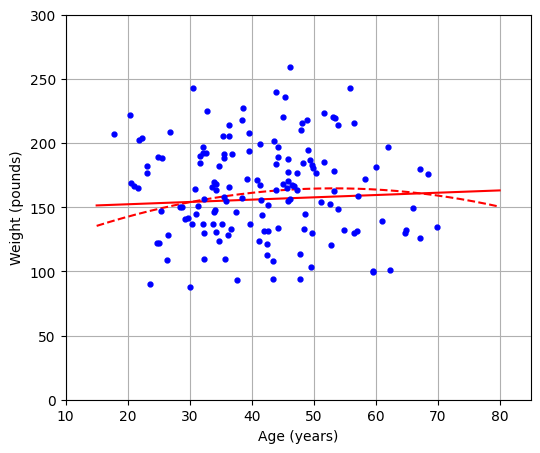

In [5]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    [15, 80],
    [148.7 + 0.18 * 15, 148.7 + 1.8 * 8],
    'r-',
    label='linear',
)
ax.plot(
    numpy.arange(15, 80, 0.1),
    [108 + 2.13 * ai - 0.02 * ai * ai for ai in numpy.arange(15, 80, 0.1)],
    'r--',
    label='quadratic',
)
ax.plot(ages, weights, 'b.', markersize=7)
ax.set_ylabel('Weight (pounds)')
ax.set_xlabel('Age (years)')
ax.grid()
ax.set_ylim(0, 300)
ax.set_xlim(10, 85)
ax.set_axisbelow(True)

## 12.2, Plotting regression with a continuous variable broken into categories

> Continuing Exercise 12.1, we divide age into 4 categories and create
> corresponding indicator variables, `age18_29`, `age30_44`, `age45_64`, and
> `age65_up`. We then fit the following regression:

```
   stan_glm(weight ~ age30_44 + age45_64 + age65_up, data=earnings)

            Median MAD_SD
(Intercept) 147.8    1.6
age30_44TRUE  9.6    2.1
age45_64TRUE 16.6    2.3
age65_upTRUE  7.5    2.7

Auxiliary parameter(s):
      Median MAD_SD
sigma 34.1    0.6
```

> (a) Why did we not include an indicator for the youngest group, `age18_29`?
>
> (b) Using the same axes and scale as in your graph for Exercise 12.1, sketch
>     with pen on paper the scatterplot, along with the above regression
>     function, which will be discontinuous.

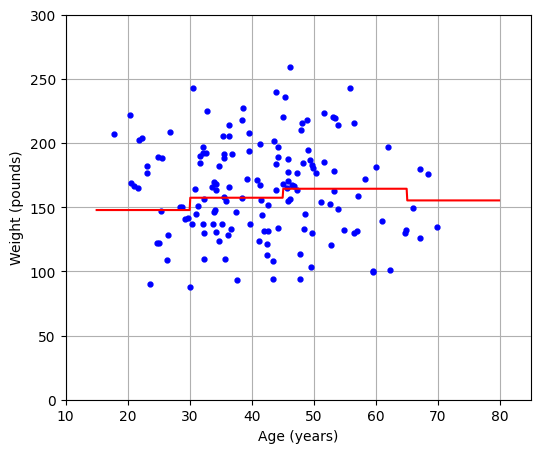

In [6]:
def discretized_age_model(age: float) -> float:
    intercept = 147.8
    if age < 30:
        return intercept
    if age < 45:
        return intercept + 9.6
    if age < 65:
        return intercept + 16.6
    return intercept + 7.5

fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(ages, weights, 'b.', markersize=7)
ax.plot(
    numpy.arange(15, 80, 0.1),
    [discretized_age_model(ai) for ai in numpy.arange(15, 80, 0.1)],
    'r-',
)
ax.set_ylabel('Weight (pounds)')
ax.set_xlabel('Age (years)')
ax.grid()
ax.set_ylim(0, 300)
ax.set_xlim(10, 85)
ax.set_axisbelow(True)

## 12.5, Logarithmic transformation and regression

> Consider the following regression:
>
> $$\log(\text{weight}) = -3.8 + 2.1 \log(\text{height}) + \text{error}$$
> 
> with errors that have standard deviation 0.25. Weights are in pounds and
> heights are in inches.
> 
> (a) Fill in the blanks: Approximately 68% of the people will have weights
>     within a factor of __ and of __ their predicted values from the
>     regression.
>
> (b) Using pen and paper, sketch the regression line and scatterplot of
>     log(weight) versus log(height) that make sense and are consistent with the
>     fitted model. Be sure to label the axes of your graph.

In [7]:
rng = fresh_prng(".5, Logarithmic transformation and regression")

n = 150

In [8]:
h_mu = 68
h_sig = 2.8
height = stats.truncnorm.rvs(
    (50 - h_mu) / h_sig,
    (84 - h_mu) / h_sig,
    loc=h_mu,
    scale=h_sig,
    size=50,
)
log_height = numpy.log(height)

log_weight = rng.normal(
    loc=(-3.8 + 2.1 * log_height),
    scale=0.25,
)

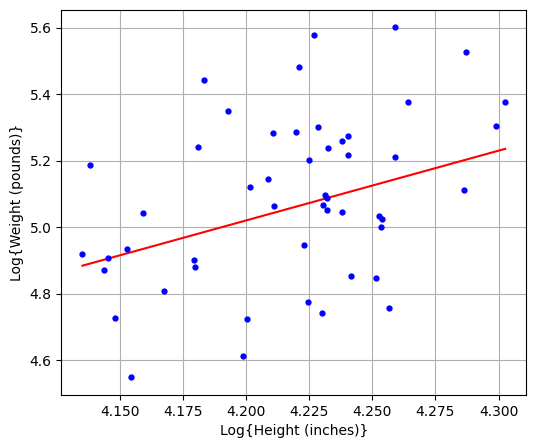

In [9]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    [min(log_height), max(log_height)],
    [-3.8 + 2.1 * lhi for lhi in [min(log_height), max(log_height)]],
    'r-',
)
ax.plot(log_height, log_weight, 'b.', markersize=7)
ax.set_ylabel('Log{Weight (pounds)}')
ax.set_xlabel('Log{Height (inches)}')
ax.grid()
ax.set_axisbelow(True)

## 12.6, Logarithmic transformations

> [The folder `Pollution`](https://github.com/avehtari/ROS-Examples/tree/master/Pollution)
> contains mortality rates and various environmental factors from 60 U.S.
> metropolitan areas (see McDonald and Schwing, 1973). For this exercise we
> shall model mortality rate given nitric oxides, sulfur dioxide, and
> hydrocarbons as inputs. This model is an extreme oversimplification, as it
> combines all sources of mortality and does not adjust for crucial factors such
> as age and smoking. We use it to illustrate log transformations in regression.
>
> (a) Create a scatterplot of mortality rate versus level of nitric oxides. Do
>     you think linear regression will fit these data well? Fit the regression
>     and evaluate a residual plot from the regression.
>
> (b) Find an appropriate transformation that will result in data more
>     appropriate for linear regression. Fit a regression to the transformed
>     data and evaluate the new residual plot.
>
> (c) Interpret the slope coefficient from the model you chose in (b).
>
> (d) Now fit a model predicting mortality rate using levels of nitric oxides,
>     sulfur dioxide, and hydrocarbons as inputs. Use appropriate
>     transformations when helpful. Plot the fitted regression model and
>     interpret the coefficients.
> 
> (e) Cross validate: fit the model you chose above to the first half of the
>     data and then predict for the second half. You used all the data to
>     construct the model in (d), so this is not really cross validation, but it
>     gives a sense of how the steps of cross validation can be implemented.

In [10]:
with open('/home/bgawalt/ros/datasets/pollution.csv') as infile:
    rows = [row for row in csv.DictReader(infile)]
nox = [int(row['nox']) for row in rows]
mort = [float(row['mort']) for row in rows]

### 12.6(a)

In [11]:
nox_linear_model = stats.linregress(nox, mort)

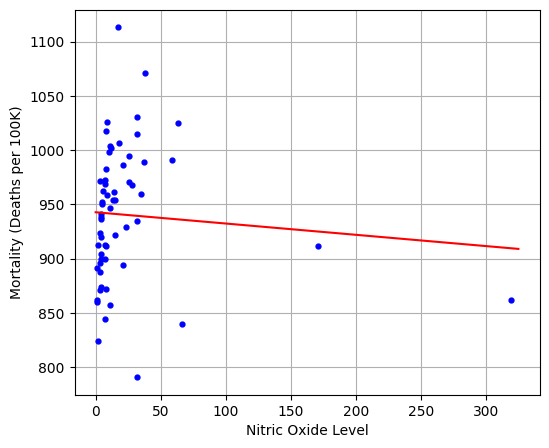

In [12]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(nox, mort, 'b.', markersize=7)
ax.plot(
    [0, 325],
    [
        nox_linear_model.intercept,
        nox_linear_model.intercept + 325 * nox_linear_model.slope,
    ],
    'r-',
)
ax.grid()
ax.set_xlabel('Nitric Oxide Level')
ax.set_ylabel('Mortality (Deaths per 100K)')
ax.set_axisbelow(True)

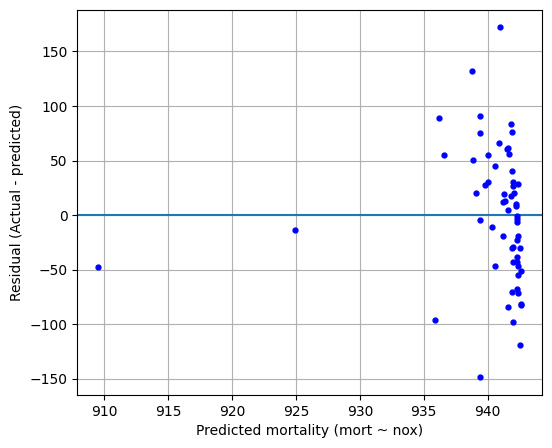

In [13]:
preds = [nox_linear_model.intercept + nox_linear_model.slope * nox_i for nox_i in nox]
resids = [actual - pred for (actual, pred) in zip(mort, preds)]

fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(preds, resids, 'b.', markersize=7)
ax.set_xlabel('Predicted mortality (mort ~ nox)')
ax.set_ylabel('Residual (Actual - predicted)')
ax.axhline(zorder=1)
ax.grid()
ax.set_axisbelow(True)

### 12.6(b)

In [14]:
log_nox = numpy.log(nox)
nox_log_model = stats.linregress(log_nox, mort)

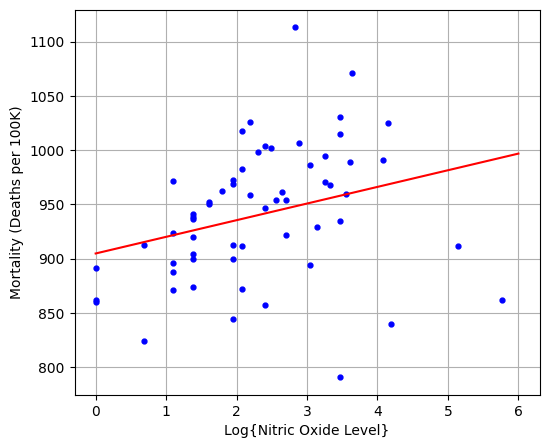

In [15]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(log_nox, mort, 'b.', markersize=7)
ax.plot(
    [0, 6],
    [
        nox_log_model.intercept,
        nox_log_model.intercept + 6 * nox_log_model.slope,
    ],
    'r-',
)
ax.grid()
ax.set_xlabel('Log{Nitric Oxide Level}')
ax.set_ylabel('Mortality (Deaths per 100K)')
ax.set_axisbelow(True)

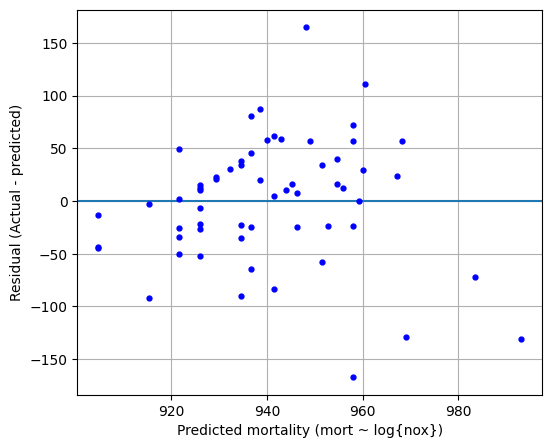

In [16]:
preds = [nox_log_model.intercept + nox_log_model.slope * lni for lni in log_nox]
resids = [actual - pred for (actual, pred) in zip(mort, preds)]

fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(preds, resids, 'b.', markersize=7)
ax.set_xlabel('Predicted mortality (mort ~ log{nox})')
ax.set_ylabel('Residual (Actual - predicted)')
ax.axhline(zorder=1)
ax.grid()
ax.set_axisbelow(True)

In [17]:
print(nox_log_model.slope, nox_log_model.stderr)
print(nox_log_model.slope * numpy.log(1.1))

15.33549673242175 6.595781794976878
1.4616289509557545


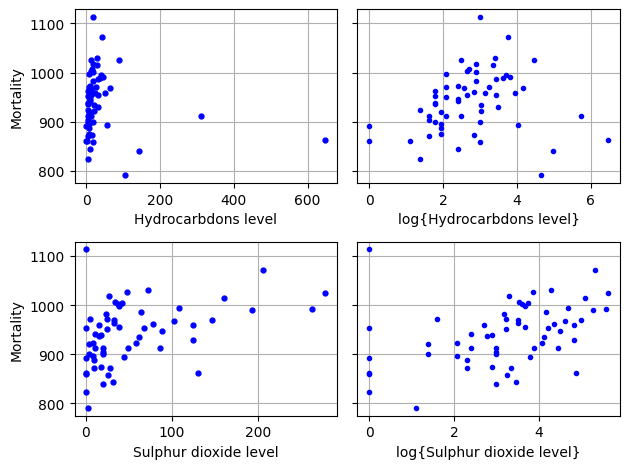

In [18]:
hc = [int(row['hc']) for row in rows]
so2 = [int(row['so2']) for row in rows]

fig, axs = pyplot.subplots(nrows=2, ncols=2, sharey=True)
for i, (xs, xname) in enumerate([(hc, 'Hydrocarbdons level'), (so2, 'Sulphur dioxide level')]):
    axs[i, 0].plot(xs, mort, 'b.', markersize=7)
    axs[i, 0].set_xlabel(xname)
    axs[i, 0].set_ylabel('Mortality')
    axs[i, 0].grid()
    axs[i, 0].set_axisbelow(True)
    axs[i, 1].plot(numpy.log(xs), mort, 'b.')
    axs[i, 1].set_xlabel('log{' + xname + '}')
    axs[i, 1].grid()
    axs[i, 1].set_axisbelow(True)
pyplot.tight_layout()
    

### 12.6(d)

In [19]:
mort_df = pandas.DataFrame(data={
    'mort': mort,
    'log_nox': log_nox,
    'log_hc': numpy.log(hc),
    'log_so2': numpy.log(so2),
})

In [20]:
mort_log_all_model = bambi.Model('mort ~ log_nox + log_hc + log_so2', mort_df)
mort_log_all_fit = mort_log_all_model.fit()
arviz.summary(mort_log_all_fit)

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/venv/ros/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_nox, log_hc, log_so2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,55.367,5.298,45.849,65.160,0.099,0.109,2939.0,2488.0,1.0
Intercept,923.692,22.158,882.046,967.244,0.388,0.312,3254.0,3069.0,1.0
log_nox,56.019,22.004,15.408,99.288,0.458,0.390,2304.0,2268.0,1.0
log_hc,-55.136,19.644,-94.386,-19.036,0.400,0.333,2403.0,2500.0,1.0
log_so2,12.015,7.209,-1.193,25.781,0.135,0.114,2857.0,2502.0,1.0


In [21]:
for b in [55.619, -54.910, 12.134]:
    print(b * numpy.log(1.1))

5.301056890536748
-5.233481973055482
1.1564937217456788


In [22]:
b_hc = []
b_so2 = []
b_nox = []
for chain in range(4):
    sims = mort_log_all_fit.posterior.sel(chain=chain).to_dataframe()
    for _, row in sims.iterrows():
        b_hc.append(row['log_hc'])
        b_nox.append(row['log_nox'])
        b_so2.append(row['log_so2'])

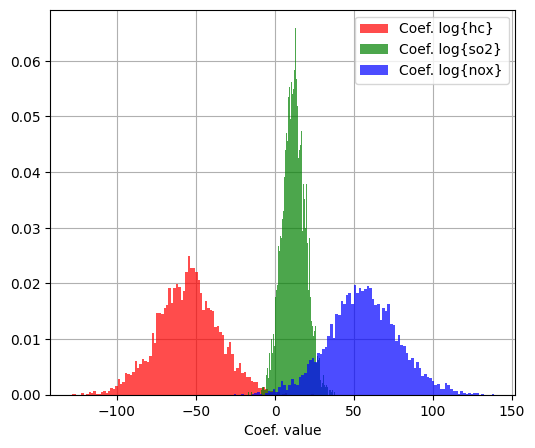

In [23]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.hist(b_hc, bins=100, color='r', alpha=0.7, label='Coef. log{hc}', density=True)
ax.hist(b_so2, bins=100, color='g', alpha=0.7, label='Coef. log{so2}', density=True)
ax.hist(b_nox, bins=100, color='b', alpha=0.7, label='Coef. log{nox}', density=True)
ax.grid()
ax.legend()
ax.set_xlabel('Coef. value')
ax.set_axisbelow(True)

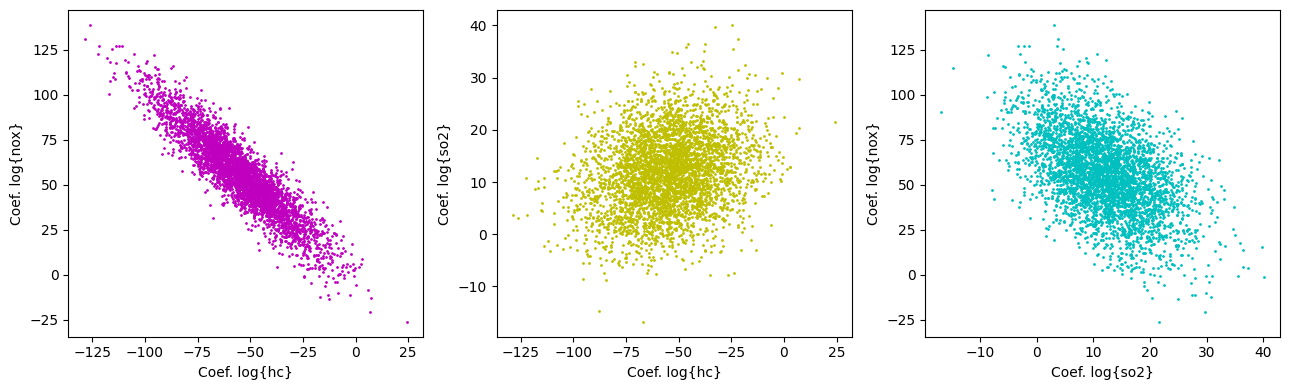

In [24]:
fig, axs = pyplot.subplots(nrows=1, ncols=3, figsize=(13, 4))
axs[0].plot(b_hc, b_nox, 'm.', markersize=2)
axs[0].set_xlabel('Coef. log{hc}')
axs[0].set_ylabel('Coef. log{nox}')
axs[1].plot(b_hc, b_so2, 'y.', markersize=2)
axs[1].set_xlabel('Coef. log{hc}')
axs[1].set_ylabel('Coef. log{so2}')
axs[2].plot(b_so2, b_nox, 'c.', markersize=2)
axs[2].set_xlabel('Coef. log{so2}')
axs[2].set_ylabel('Coef. log{nox}')
pyplot.tight_layout()

### 12.6(3)

In [25]:
n = len(mort)
mort_train_df = pandas.DataFrame(data={
    'mort': mort[:int(n/2)],
    'log_nox': log_nox[:int(n/2)],
    'log_hc': numpy.log(hc[:int(n/2)]),
    'log_so2': numpy.log(so2[:int(n/2)]),
})
mort_test_df = pandas.DataFrame(data={
    'mort': mort[int(n/2):],
    'log_nox': log_nox[int(n/2):],
    'log_hc': numpy.log(hc[int(n/2):]),
    'log_so2': numpy.log(so2[int(n/2):]),
})

In [26]:
mort_cv_model = bambi.Model('mort ~ log_nox + log_hc + log_so2', mort_train_df)
mort_cv_fit = mort_cv_model.fit()
mort_cv_model.predict(mort_cv_fit, kind="response", data=mort_test_df)
preds_df = mort_cv_fit.posterior.mean(dim=["chain", "draw"])["mu"].to_dataframe()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_nox, log_hc, log_so2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


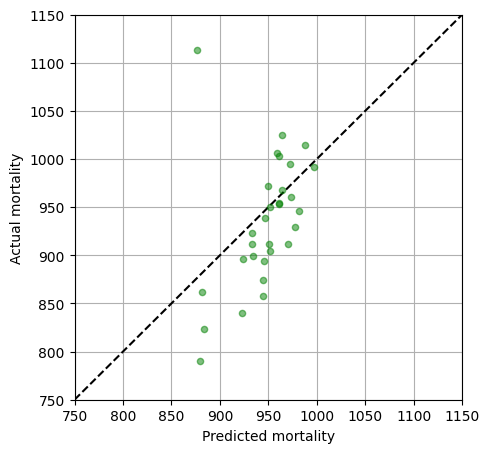

In [27]:
fig = pyplot.figure(figsize=(5, 5))
ax = fig.gca()
ax.plot([750, 1150], [750, 1150], 'k--')
ax.set_ylim(750, 1150)
ax.set_xlim(750, 1150)
ax.plot(preds_df["mu"], mort_test_df["mort"], 'g.', markersize=9, alpha=0.5)
ax.set_xlabel('Predicted mortality')
ax.set_ylabel('Actual mortality')
ax.grid()
ax.set_axisbelow(True)

## 12.15, Models for regression coefficients

> Using the Portuguese student data from 
> [the `Student` folder](https://github.com/avehtari/ROS-Examples/blob/master/Student/),
> repeat the analyses in Section 12.7 with the same predictors, but using as
> outcome the Portuguese language grade rather than the mathematics grade.

In [49]:
predictors = [
    "school", "sex", "age", "address", "famsize", "Pstatus", "Medu", "Fedu",
    "traveltime", "studytime", "failures", "schoolsup", "famsup", "paid",
    "activities", "nursery", "higher", "internet", "romantic", "famrel",
    "freetime", "goout", "Dalc", "Walc", "health", "absences",
]
formula = 'G3por ~ ' + ' + '.join(predictors)
student_df = pandas.read_csv('/home/bgawalt/ros/datasets/student-merged.csv')[['G3por',] + predictors]

In [58]:
n = student_df.shape[0]

(382, 27)


In [50]:
student_z_df = pandas.DataFrame(data={'G3por': student_df['G3por']})
for pred in predictors:
    mu = numpy.mean(student_df[pred])
    sig = numpy.std(student_df[pred])
    student_z_df[pred] = (student_df[pred] - mu) / sig

In [51]:
stud1_orig_model = bambi.Model(formula, student_df)
stud1_orig_fit = stud1_orig_model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, school, sex, age, address, famsize, Pstatus, Medu, Fedu, traveltime, studytime, failures, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic, famrel, freetime, goout, Dalc, Walc, health, absences]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [52]:
stud2_z_model = bambi.Model(formula, student_z_df)
stud2_z_fit = stud2_z_model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, school, sex, age, address, famsize, Pstatus, Medu, Fedu, traveltime, studytime, failures, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic, famrel, freetime, goout, Dalc, Walc, health, absences]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Text(0.5, 1.0, 'With standardization')

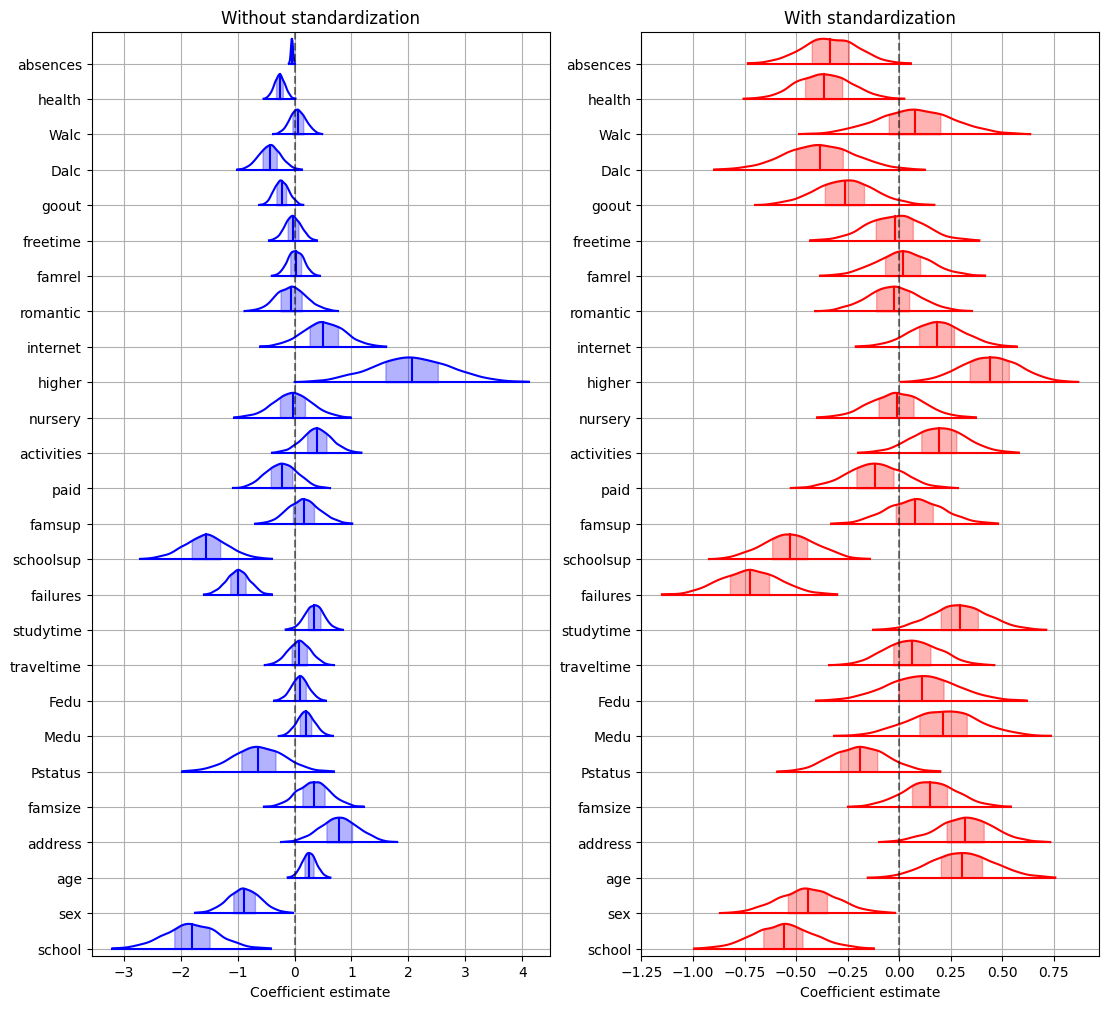

In [53]:
fig, axs = pyplot.subplots(nrows=1, ncols=2, figsize=(13, 12))
bg_ros.plot_ridge(axs[0], stud1_orig_fit, predictors, color='b')
axs[0].set_title('Without standardization')
bg_ros.plot_ridge(axs[1], stud2_z_fit, predictors, color='r')
axs[1].set_title('With standardization')

In [54]:
sd_y = numpy.std(student_z_df['G3por'])
prior_sd = sd_y * numpy.sqrt(0.3 / len(predictors))
priors3_normal = {
    'common': bambi.Prior('Normal', sigma=prior_sd),
    'sigma': bambi.Prior('Exponential', lam=(numpy.sqrt(0.7) * sd_y)),
}
stud3_normal_model = bambi.Model(formula, student_z_df, priors=priors3_normal)
stud3_normal_fit = stud3_normal_model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, school, sex, age, address, famsize, Pstatus, Medu, Fedu, traveltime, studytime, failures, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic, famrel, freetime, goout, Dalc, Walc, health, absences]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [64]:
# Thanks to https://github.com/bambinos/bambi/issues/968
def RegularizedHorseshoe(
    name,
    scale_global,
    scale_slab,
    nu_global=4,  # nu_global in Stan
    nu_local=1,  # nu_local in Stan
    slab_df=4,  # slab_df in Stan
    shape=None,
    dims=None,
):
    if dims is None and shape is not None:
        dims = f"{name}_dim"

    tau = pymc.HalfStudentT(f"{name}_tau", nu=nu_global, sigma=scale_global)
    lam = pymc.HalfStudentT(f"{name}_lam", nu=nu_local, sigma=1.0, dims=dims)

    caux = pymc.InverseGamma(f"{name}_caux", alpha=slab_df / 2, beta=slab_df / 2)

    c2 = pymc.Deterministic(f"{name}_c2", scale_slab**2 * caux)

    z = pymc.Normal(f"{name}_z", 0.0, 1.0, dims=dims)

    lam_tilde = pymc.Deterministic(
        f"{name}_lam_tilde",
        pymc.math.sqrt((c2 * lam**2) / (c2 + tau**2 * lam**2)),
        dims=dims,
    )

    beta = pymc.Deterministic(name, z * tau * lam_tilde, dims=dims)

    return beta

In [123]:
term_name = "c(" + ", ".join(predictors[::-1]) + ")"
formula4 = f"G3por ~ {term_name}"
p0 = 6
slab_scale = numpy.sqrt(0.3 / p0) * sd_y
global_scale = (p0 / (len(predictors) - p0)) / n
priors4 = {
    term_name: bambi.Prior(
        "RegularizedHorseshoe",
        scale_global=global_scale,
        scale_slab=slab_scale,
        dist=RegularizedHorseshoe,
    )
}
stud4_rhs_model = bambi.Model(formula4, student_z_df, priors=priors4)
aliases = {term_name: "predictors"}
for i, pred in enumerate(predictors):
    aliases[f'predictors[{i}]'] = pred
stud4_rhs_model.set_alias(aliases)
stud4_rhs_fit = stud4_rhs_model.fit(target_accept=0.9)

/home/bgawalt/venv/ros/lib/python3.10/site-packages/bambi/models.py:611: UserWarning: There are 26 names that do not match any terms, so their aliases were not assigned.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, predictors_tau, predictors_lam, predictors_caux, predictors_z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


Text(0.5, 1.0, 'Regularized Horseshoe prior (p0 = 6)')

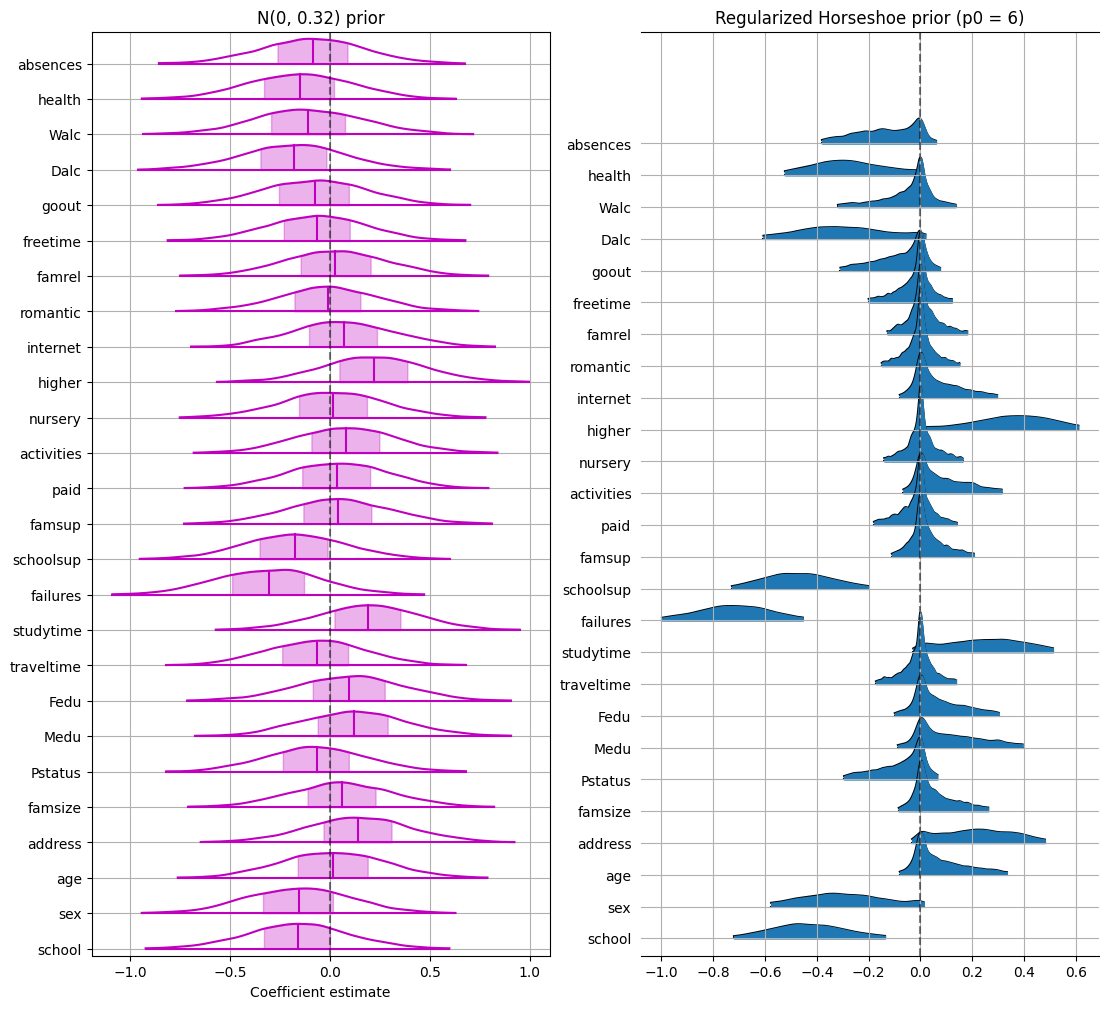

In [133]:
fig, axs = pyplot.subplots(nrows=1, ncols=2, figsize=(13, 12))
bg_ros.plot_ridge(axs[0], stud3_normal_fit, predictors, color='m')
axs[0].set_title(f'N(0, {prior_sd:0.2f}) prior')
arviz.plot_forest(stud4_rhs_fit, var_names=["predictors"], kind='ridgeplot', combined=True, backend='matplotlib', ax=axs[1])
axs[1].set_yticklabels(predictors)
axs[1].grid()
axs[1].set_axisbelow(True)
axs[1].axvline(x=0, linestyle='--', color='k', zorder=100, alpha=0.5)
axs[1].set_title('Regularized Horseshoe prior (p0 = 6)')